**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
Dr. Irvin Hussein López Nava

## ICD - 4: Visualización

Sesión 4 del curso. Diapositivas: [icd-04-visualizacion.pdf](https://github.com/husseinlopez/icd2026/blob/main/clases/icd-04-visualizacion.pdf)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/husseinlopez/icd2026/blob/main/icd-04-visualizacion.ipynb)

En la sesión anterior dejamos una tabla limpia y utilizable. La pregunta que sigue es qué hacer con ella, y la respuesta de esta sesión es mirarla. No por adorno: porque hay cosas que ningún resumen numérico muestra y que una gráfica revela de inmediato.

Este notebook recorre un análisis exploratorio completo sobre datos reales, con **matplotlib** y **seaborn**. Vamos del contexto del conjunto a los hallazgos, pasando por la revisión de calidad y por el análisis univariado, bivariado y multivariado.

Dos ideas organizan el documento, y las dos vienen de las diapositivas:

- **Cada figura responde una pregunta.** No se grafica una columna porque exista, sino porque hay algo que averiguar sobre ella.
- **Cada figura se lee.** Debajo de cada gráfica hay un párrafo que dice qué se observa y qué implica. Una figura sin lectura obliga a quien lee a adivinar la conclusión, o a confiar en que la hay.

A diferencia de la sesión anterior, aquí el conjunto de datos no es ficticio ni está sucio a propósito: viene tal cual de su fuente, con los defectos que traía.

---

### Preparación

Las dos librerías de la sesión, sobre las dos de la sesión anterior. La convención `plt` / `sns` es tan universal como `np` / `pd`: se escribe así en toda la documentación.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("numpy     ", np.__version__)
print("pandas    ", pd.__version__)
print("matplotlib", __import__("matplotlib").__version__)
print("seaborn   ", sns.__version__)

numpy      2.4.4
pandas     3.0.2
matplotlib 3.10.8
seaborn    0.13.2


Una paleta y un tema definidos una sola vez, al inicio, evitan que cada gráfica termine con colores distintos por accidente. Los colores son los de las diapositivas del curso.

In [2]:
AZUL_OSCURO = "#112057"
AZUL = "#7697CD"
AZUL_CLARO = "#BFD5EA"
ROJO = "#C0392B"

sns.set_theme(style="whitegrid", palette=[AZUL_OSCURO, AZUL, AZUL_CLARO, ROJO])
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlecolor"] = AZUL_OSCURO
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

---

### Los datos

**Evaluaciones sensoriales de café verde del Coffee Quality Institute.**

Catadores certificados califican cada lote en diez subescalas —aroma, sabor, retrogusto, acidez, cuerpo, balance, uniformidad, taza limpia, dulzor y puntaje del catador—, cada una de 0 a 10. La tabla incluye además atributos del lote: país de origen, variedad, método de beneficio, altitud, defectos y humedad.

- **Quién lo recolectó.** El Coffee Quality Institute mantiene la base. James LeDoux la extrajo y publicó en [jldbc/coffee-quality-database](https://github.com/jldbc/coffee-quality-database); la versión que usamos es la redistribuida por [TidyTuesday](https://github.com/rfordatascience/tidytuesday/tree/master/data/2020/2020-07-07) el 7 de julio de 2020.
- **Cuándo.** Cosechas de 2010 a 2018 aproximadamente.
- **Unidad de observación.** Un lote de café evaluado. No es un productor, ni una finca, ni un país: un mismo productor puede aparecer en varias filas. Confundir la unidad de observación es el error más caro de un análisis exploratorio, porque contamina todos los promedios que se calculen después.
- **Licencia.** El repositorio de origen no declara una licencia explícita. Para el uso académico de esta sesión basta con citar la fuente. Cuando la licencia no está declarada, lo correcto es decirlo así y no suponerla.

Como en la sesión anterior, hay dos formas de cargar el archivo:

- **En tu máquina.** Clona el repositorio y abre el notebook desde la carpeta clonada; la ruta a `datos/` funciona tal cual.
- **En Colab.** Comenta la primera línea y descomenta la segunda.

In [3]:
crudo = pd.read_csv("datos/cafe-calidad.csv")
# crudo = pd.read_csv("https://raw.githubusercontent.com/husseinlopez/icd2026/main/datos/cafe-calidad.csv")

print(f"{crudo.shape[0]} registros × {crudo.shape[1]} atributos")
crudo.head()

1339 registros × 43 atributos


,total_cup_points,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,region,producer,number_of_bags,bag_weight,in_country_partner,harvest_year,grading_date,owner_1,variety,processing_method,aroma,flavor,aftertaste,acidity,body,balance,uniformity,clean_cup,sweetness,cupper_points,moisture,category_one_defects,quakers,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,90.58,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,NaN,Washed / Wet,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,0.12,0,0.0,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,89.92,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Other,Washed / Wet,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,0.12,0,0.0,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,89.75,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,NaN,NaN,5,1,Specialty Coffee Association,NaN,"May 31st, 2010",Grounds for Health Admin,Bourbon,NaN,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,0.00,0,0.0,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,89.00,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,oromia,Yidnekachew Dabessa Coffee Plantation,320,60 kg,METAD Agricultural Development plc,2014,"March 26th, 2015",Yidnekachew Dabessa,NaN,Natural / Dry,8.17,8.58,8.42,8.42,8.50,8.25,10.0,10.0,10.0,8.67,0.11,0,0.0,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,88.83,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Other,Washed / Wet,8.25,8.50,8.25,8.50,8.42,8.33,10.0,10.0,10.0,8.58,0.12,0,0.0,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


### Verificación inicial

Antes de analizar conviene confirmar qué se cargó: cuántos registros, de qué tipos, y si hay problemas visibles desde la entrada. Descubrir aquí que el archivo se leyó mal es mucho más barato que descubrirlo veinte celdas más adelante.

In [4]:
n_filas, n_columnas = crudo.shape
n_numericas = crudo.select_dtypes(include="number").shape[1]
n_no_numericas = crudo.select_dtypes(exclude="number").shape[1]

print(f"Registros:               {n_filas:>5}")
print(f"Atributos:               {n_columnas:>5}")
print(f"  numéricos:             {n_numericas:>5}")
print(f"  no numéricos:          {n_no_numericas:>5}")
print(f"Duplicados exactos:      {crudo.duplicated().sum():>5}")
print(f"Registros con faltantes: {crudo.isna().any(axis=1).sum():>5}")

Registros:                1339
Atributos:                  43
  numéricos:                19
  no numéricos:             24
Duplicados exactos:          0
Registros con faltantes:  1207


Un detalle de la celda anterior: se usa `select_dtypes(exclude="number")` y no `select_dtypes(include=["object", "category"])`. A partir de pandas 3.0 las columnas de texto tienen tipo `str` y ya no `object`, así que la segunda forma devolvería cero columnas categóricas en un entorno reciente. Preguntar **qué no es numérico** es más estable que enumerar los tipos que sí.

### Subconjunto de trabajo

El archivo trae 43 columnas, muchas de ellas administrativas: número de lote, dirección de la certificadora, contacto. Nos quedamos con 21 relevantes para la evaluación del lote.

Reducir columnas al inicio es legítimo siempre que la decisión quede escrita. Lo que no es legítimo es reducirlas en silencio: quien lea el análisis debe poder saber qué se dejó fuera y por qué.

In [5]:
COLUMNAS_IDENTIDAD = ["species", "country_of_origin", "harvest_year",
                      "variety", "processing_method", "color"]

COLUMNAS_SENSORIALES = ["aroma", "flavor", "aftertaste", "acidity", "body",
                        "balance", "uniformity", "clean_cup", "sweetness",
                        "cupper_points"]

COLUMNAS_FISICAS = ["moisture", "category_one_defects", "category_two_defects",
                    "altitude_mean_meters"]

COLUMNAS_TRABAJO = (["total_cup_points"] + COLUMNAS_IDENTIDAD
                    + COLUMNAS_SENSORIALES + COLUMNAS_FISICAS)

lotes = crudo[COLUMNAS_TRABAJO].copy()
lotes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_cup_points      1339 non-null   float64
 1   species               1339 non-null   str    
 2   country_of_origin     1338 non-null   str    
 3   harvest_year          1292 non-null   str    
 4   variety               1113 non-null   str    
 5   processing_method     1169 non-null   str    
 6   color                 1069 non-null   str    
 7   aroma                 1339 non-null   float64
 8   flavor                1339 non-null   float64
 9   aftertaste            1339 non-null   float64
 10  acidity               1339 non-null   float64
 11  body                  1339 non-null   float64
 12  balance               1339 non-null   float64
 13  uniformity            1339 non-null   float64
 14  clean_cup             1339 non-null   float64
 15  sweetness             1339 non-n

Los nombres de columna se conservan en inglés, tal como vienen de la fuente. Traducirlos rompería la correspondencia con la documentación original del conjunto, que es donde hay que ir a resolver cualquier duda sobre qué mide cada atributo. Los nombres que sí elegimos nosotros —variables, funciones, constantes— van en español, como en el resto del curso.

---

## 1. Calidad de los datos

Esta es la sección que ningún análisis apurado incluye y sin la cual todo lo demás puede estar mal. Revisamos cuatro cosas: qué falta, qué está repetido, qué es imposible y qué está codificado de forma inconsistente.

### Valores faltantes

Interesa el **patrón** de ausencia, no solo el conteo. Un dato que falta al azar es un problema menor; un dato que falta sistemáticamente en un subgrupo es un sesgo.

In [6]:
proporcion_faltantes = lotes.isna().mean().sort_values(ascending=False)
proporcion_faltantes = proporcion_faltantes[proporcion_faltantes > 0]

pd.DataFrame({
    "faltantes": lotes.isna().sum()[proporcion_faltantes.index],
    "porcentaje": (proporcion_faltantes * 100).round(1),
})

,faltantes,porcentaje
color,270,20.2
altitude_mean_meters,230,17.2
variety,226,16.9
processing_method,170,12.7
harvest_year,47,3.5
country_of_origin,1,0.1


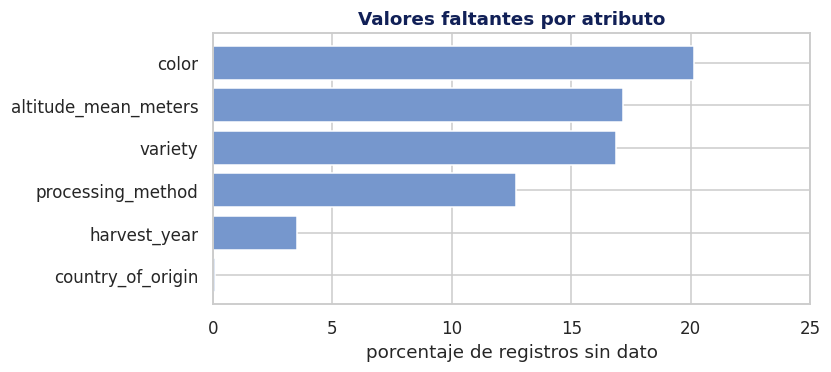

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))

# Barras horizontales: la longitud es el canal más preciso después de la posición,
# y las etiquetas de columna se leen sin girar la cabeza.
ax.barh(proporcion_faltantes.index[::-1],
        proporcion_faltantes.values[::-1] * 100, color=AZUL)

ax.set_xlabel("porcentaje de registros sin dato")
ax.set_title("Valores faltantes por atributo")
ax.set_xlim(0, 25)
plt.show()

**Lectura.** Seis atributos tienen ausencias. Tres superan el 12 %: `color` (20 %), `altitude_mean_meters` (17 %) y `variety` (17 %). Los quince restantes están completos, lo cual tiene sentido: las subescalas sensoriales son el motivo mismo de la evaluación, mientras que la altitud y la variedad dependen de que el productor las haya reportado.

Esa diferencia sugiere que la ausencia **no es aleatoria**. Vale la pena comprobarlo antes de decidir qué hacer con ella.

In [8]:
# ¿La altitud falta por igual en todos los países? Solo se consideran los países
# con al menos 30 lotes, para que el porcentaje sea interpretable.
faltantes_altitud = (
    lotes.groupby("country_of_origin")["altitude_mean_meters"]
    .agg(lotes="size", sin_altitud=lambda valores: valores.isna().mean())
    .query("lotes >= 30")
    .sort_values("sin_altitud", ascending=False)
)

(faltantes_altitud["sin_altitud"] * 100).round(1).head(8)

country_of_origin
United States (Hawaii)          97.3
Thailand                        37.5
Ethiopia                        31.8
Brazil                          20.5
Colombia                        18.0
Guatemala                       13.8
Costa Rica                       9.8
Tanzania, United Republic Of     7.5
Name: sin_altitud, dtype: float64

**Lectura.** La ausencia está lejos de ser aleatoria: en los lotes de Hawái falta la altitud en el 97 % de los casos, contra el 14 % de Guatemala. Cualquier análisis que elimine las filas sin altitud estaría eliminando, en la práctica, casi todo Hawái.

Por eso aquí **no se imputan ni se eliminan los faltantes**: se documentan. Imputar antes de explorar borra justamente el patrón que se acaba de descubrir.

### Registros duplicados

Un duplicado exacto casi siempre es un error de captura. Un duplicado parcial —dos filas con los mismos identificadores pero distintos valores— es más interesante, porque puede significar que la unidad de observación no es la que se creía.

In [9]:
print("Duplicados exactos:", lotes.duplicated().sum())
print("Duplicados en los atributos de identidad:",
      lotes.duplicated(subset=COLUMNAS_IDENTIDAD).sum())

Duplicados exactos: 0
Duplicados en los atributos de identidad: 756


**Lectura.** No hay duplicados exactos. Sí hay muchas filas que comparten los seis atributos de identidad, lo cual era de esperarse: varios lotes distintos pueden venir del mismo país, la misma variedad y el mismo año. Esto **confirma** lo que dijimos al presentar los datos: la unidad de observación es el lote, no el productor ni la región. La coincidencia no es un error.

### Valores imposibles y fuera de rango

«Imposible» y «atípico» no son lo mismo. Un valor atípico puede ser real y valiosísimo; un valor imposible viola la definición de la variable. El primero se investiga, el segundo se corrige.

In [10]:
# El puntaje total es la suma de las diez subescalas, cada una de 0 a 10.
# Un cero significaría que el lote obtuvo cero en las diez, incluida la uniformidad.
puntajes_imposibles = lotes[lotes["total_cup_points"] == 0]
puntajes_imposibles[["total_cup_points"] + COLUMNAS_SENSORIALES]

,total_cup_points,aroma,flavor,aftertaste,acidity,body,balance,uniformity,clean_cup,sweetness,cupper_points
1310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
lotes["altitude_mean_meters"].describe().round(1)

count      1109.0
mean       1775.0
std        8668.6
min           1.0
25%        1100.0
50%        1310.6
75%        1600.0
max      190164.0
Name: altitude_mean_meters, dtype: float64

**Lectura.** Dos hallazgos distintos.

El primero: un lote con puntaje total de 0 y ceros en las diez subescalas. No es un café malo, es un registro vacío que se guardó como si fuera una evaluación.

El segundo: la altitud declara un máximo de **190 164 metros**, veintiún veces la altura del Everest, y un mínimo de 1 metro. La media (1775 m) está muy por encima de la mediana (1311 m), señal clásica de que unos pocos valores extremos arrastran el promedio. Las regiones cafetaleras del mundo no superan los 3000 m, así que todo lo que esté por encima es error de captura: dígitos repetidos, o pies registrados como metros.

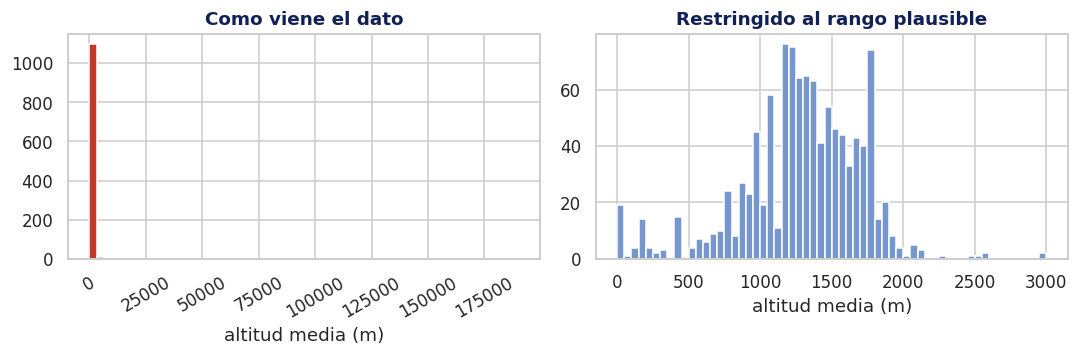

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

axes[0].hist(lotes["altitude_mean_meters"].dropna(), bins=60, color=ROJO)
axes[0].set_title("Como viene el dato")
axes[0].set_xlabel("altitud media (m)")
axes[0].tick_params(axis="x", labelrotation=30)

altitud_plausible = lotes["altitude_mean_meters"].where(
    lotes["altitude_mean_meters"].between(0, 3000)
)
axes[1].hist(altitud_plausible.dropna(), bins=60, color=AZUL)
axes[1].set_title("Restringido al rango plausible")
axes[1].set_xlabel("altitud media (m)")

plt.tight_layout()
plt.show()

**Lectura.** El panel izquierdo es inservible: un puñado de valores absurdos comprime toda la distribución real contra el eje vertical, y no se ve nada. El panel derecho, con el mismo dato restringido al rango plausible, muestra que la gran mayoría de los lotes se concentra entre los 1000 y los 1800 m, con una cola hacia los 2000 m y un grupo menor por debajo de los 500 m. Eso es lo que uno esperaría de café de altura.

Este par de gráficas es el argumento completo a favor de revisar rangos antes de graficar. La primera figura no es *fea*: es una figura correcta de un dato sucio.

### Cardinalidad y codificación inconsistente

In [13]:
resumen_categoricas = pd.DataFrame({
    "niveles": lotes[COLUMNAS_IDENTIDAD].nunique(),
    "faltantes": lotes[COLUMNAS_IDENTIDAD].isna().sum(),
    "más frecuente": [lotes[columna].mode()[0] for columna in COLUMNAS_IDENTIDAD],
})
resumen_categoricas

,niveles,faltantes,más frecuente
species,2,0,Arabica
country_of_origin,36,1,Mexico
harvest_year,46,47,2012
variety,29,226,Caturra
processing_method,5,170,Washed / Wet
color,3,270,Green


In [14]:
lotes["color"].value_counts(dropna=False)

color
Green           870
NaN             270
Bluish-Green    114
Blue-Green       85
Name: count, dtype: int64

In [15]:
lotes["harvest_year"].value_counts(dropna=False).head(12)

harvest_year
2012           354
2014           233
2013           181
2015           129
2016           124
2017            70
NaN             47
2013/2014       29
2015/2016       28
2011            26
2017 / 2018     19
2014/2015       19
Name: count, dtype: int64

**Lectura.** Dos problemas de codificación, de naturaleza distinta.

En `color` aparecen `Bluish-Green` y `Blue-Green`: **una misma categoría escrita de dos formas**. Cualquier conteo por color las trataría como colores diferentes y subestimaría ambas. Es el mismo problema que vimos en la sesión anterior con la columna `sexo`, pero aquí nadie lo puso a propósito.

En `harvest_year` conviven al menos cinco formatos: `2012`, `2013/2014`, `2017 / 2018`, `4T/10` y `March 2010`. La columna se lee como texto y, tal como está, es inutilizable para ordenar en el tiempo.

Ninguno de los dos problemas aparece en `describe()`. Solo se ven mirando los niveles de cada variable categórica, uno por uno.

### Decisiones de limpieza

Cada decisión se escribe con su justificación. Un lector debe poder estar en desacuerdo con una decisión concreta sin tener que adivinar cuál fue.

1. **Se elimina** el único lote con puntaje total de 0: no es una evaluación.
2. **Se marcan como faltantes** las altitudes fuera del rango 0–3000 m. No se elimina la fila completa, porque el resto de sus atributos es válido.
3. **Se consolidan** `Bluish-Green` y `Blue-Green` en una sola categoría.
4. **Se extrae** el primer año de cuatro dígitos de `harvest_year`. Lo que no contiene un año interpretable queda como faltante, en lugar de adivinarse.
5. **No se imputa nada.** Las ausencias documentadas arriba se conservan tal cual, por la razón explicada ahí.

In [16]:
ALTITUD_MAXIMA_PLAUSIBLE_M = 3000

def marcar_altitudes_imposibles(altitudes, metros_maximos=ALTITUD_MAXIMA_PLAUSIBLE_M):
    """Convierte en faltantes las altitudes fuera del rango plausible.

    Las regiones cafetaleras no superan los ~3000 m sobre el nivel del mar, así que
    los valores por encima de ese umbral son errores de captura y no altitudes
    reales. Se marcan como faltantes en lugar de eliminarse porque el resto de los
    atributos de esos lotes sigue siendo válido.
    """
    return altitudes.where(altitudes.between(0, metros_maximos))


def extraer_anio_cosecha(valores):
    """Extrae el primer año de cuatro dígitos de la columna de cosecha.

    La columna mezcla formatos ('2012', '2013/2014', '4T/10', 'March 2010'). Se
    conserva el primer año completo que aparezca. Lo que no contiene un año de
    cuatro dígitos queda como faltante: es preferible una ausencia declarada a un
    valor inventado.
    """
    return pd.to_numeric(valores.astype("string").str.extract(r"(\d{4})")[0])

In [17]:
lotes_limpios = lotes[lotes["total_cup_points"] > 0].copy()

lotes_limpios["altitude_mean_meters"] = marcar_altitudes_imposibles(
    lotes_limpios["altitude_mean_meters"]
)
lotes_limpios["color"] = lotes_limpios["color"].replace({"Bluish-Green": "Blue-Green"})
lotes_limpios["harvest_year"] = extraer_anio_cosecha(lotes_limpios["harvest_year"])

print(f"Antes:   {lotes.shape[0]} registros")
print(f"Después: {lotes_limpios.shape[0]} registros")
print()
print("Altitudes marcadas como faltantes:",
      int(lotes_limpios['altitude_mean_meters'].isna().sum()
          - lotes['altitude_mean_meters'].isna().sum()))
print("Niveles de color:", lotes_limpios['color'].dropna().unique().tolist())
print("Años de cosecha:",
      sorted(lotes_limpios['harvest_year'].dropna().unique().astype(int).tolist()))

Antes:   1339 registros
Después: 1338 registros

Altitudes marcadas como faltantes: 16
Niveles de color: ['Green', 'Blue-Green']
Años de cosecha: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 7201]


---

## 2. Análisis univariado

Qué forma tiene cada variable por separado. El objetivo no es producir una gráfica por columna, sino detectar las que se comportan de forma inesperada.

### Variables numéricas

In [18]:
lotes_limpios[COLUMNAS_SENSORIALES].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
aroma,1338.0,7.57,0.32,5.08,7.42,7.58,7.75,8.75
flavor,1338.0,7.53,0.34,6.08,7.33,7.58,7.75,8.83
aftertaste,1338.0,7.41,0.35,6.17,7.25,7.42,7.58,8.67
acidity,1338.0,7.54,0.32,5.25,7.33,7.58,7.75,8.75
body,1338.0,7.52,0.31,5.08,7.33,7.50,7.67,8.58
balance,1338.0,7.52,0.35,5.25,7.33,7.50,7.75,8.75
uniformity,1338.0,9.84,0.49,6.00,10.00,10.00,10.00,10.00
clean_cup,1338.0,9.84,0.72,0.00,10.00,10.00,10.00,10.00
sweetness,1338.0,9.86,0.55,1.33,10.00,10.00,10.00,10.00
cupper_points,1338.0,7.51,0.43,5.17,7.25,7.50,7.75,10.00


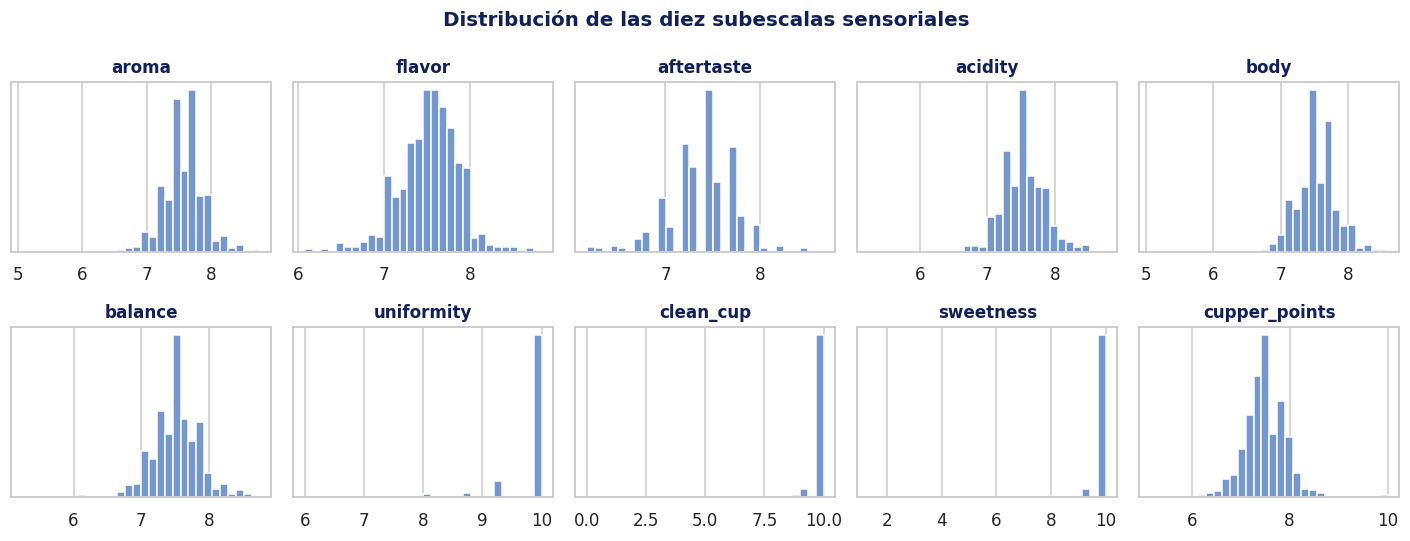

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5))

for ax, columna in zip(axes.ravel(), COLUMNAS_SENSORIALES):
    ax.hist(lotes_limpios[columna].dropna(), bins=30, color=AZUL)
    ax.set_title(columna, fontsize=11)
    ax.set_yticks([])

fig.suptitle("Distribución de las diez subescalas sensoriales",
             fontsize=13, color=AZUL_OSCURO, fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura.** Las seis primeras subescalas —aroma, sabor, retrogusto, acidez, cuerpo, balance— tienen distribuciones aproximadamente simétricas alrededor de 7.5, con colas a la izquierda. Se comportan como se esperaría de una escala de evaluación.

`uniformity`, `clean_cup` y `sweetness` se comportan de forma distinta: están saturadas contra el 10. Su mediana es exactamente 10 y su desviación estándar ronda 0.5, es decir, casi todos los lotes reciben la calificación máxima. **Una variable que casi no varía casi no informa.** Es un hallazgo, no un defecto del conjunto: dice algo sobre cómo se aplica el protocolo de catación en la práctica.

### Variables categóricas

Usamos barras y no gráficos de pastel. Con doce países el pastel codificaría en ángulo —cuarto lugar en la jerarquía de canales que vimos en clase— lo que las barras codifican en posición, que es el primero. El resultado es que en el pastel nadie podría ordenar los países, y en las barras el orden se lee de inmediato.

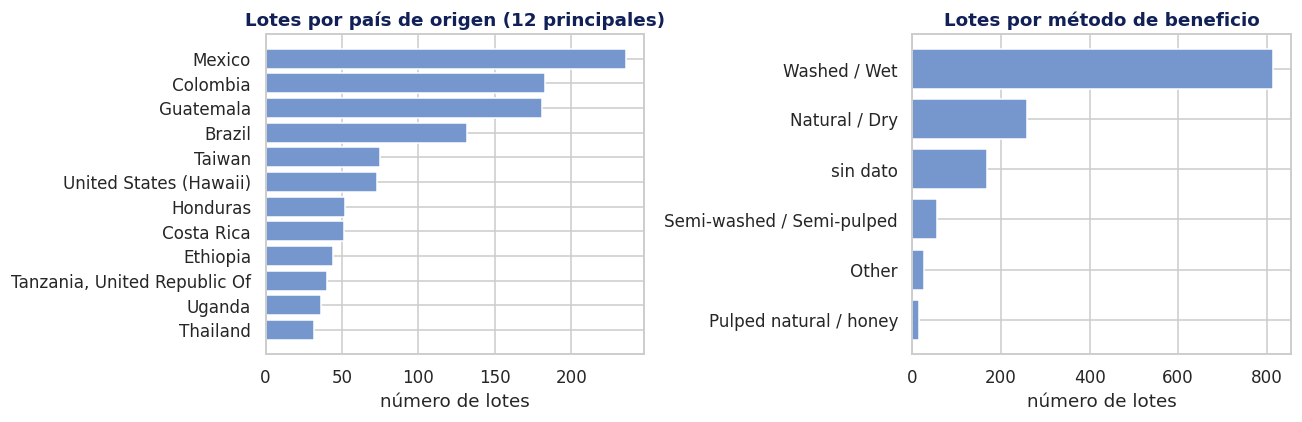

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

paises_principales = lotes_limpios["country_of_origin"].value_counts().head(12)
axes[0].barh(paises_principales.index[::-1], paises_principales.values[::-1], color=AZUL)
axes[0].set_title("Lotes por país de origen (12 principales)")
axes[0].set_xlabel("número de lotes")

metodos = lotes_limpios["processing_method"].value_counts(dropna=False)
metodos.index = metodos.index.fillna("sin dato")
axes[1].barh(metodos.index[::-1], metodos.values[::-1], color=AZUL)
axes[1].set_title("Lotes por método de beneficio")
axes[1].set_xlabel("número de lotes")

plt.tight_layout()
plt.show()

**Lectura.** México es el origen con más lotes evaluados del conjunto (236), por delante de Colombia y Guatemala. Los cuatro primeros países concentran más de la mitad de los registros, así que cualquier promedio global está dominado por esos orígenes y no describe «el café del mundo».

En el método de beneficio, la categoría más grande después de las dos dominantes es **«sin dato»**. Graficar los faltantes como una categoría más, en lugar de dejarlos fuera en silencio, es lo que permite verlo.

---

## 3. Análisis bivariado

Qué relación hay entre pares de variables. No exploramos todos los pares posibles: elegimos los que responden a una pregunta.

**Pregunta 1.** ¿Qué tanto determina el sabor la calificación final del lote?

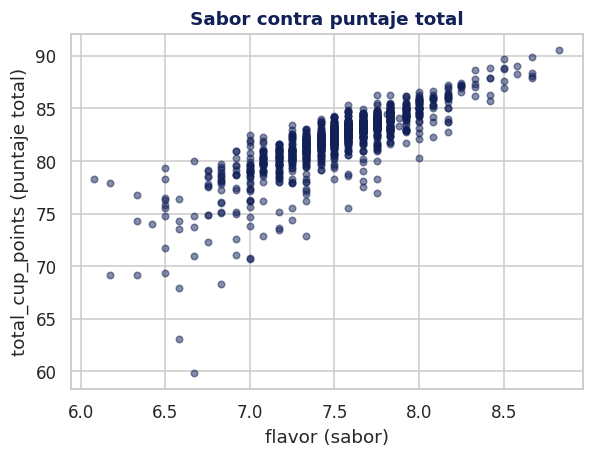

In [21]:
fig, ax = plt.subplots(figsize=(6, 4.2))

ax.scatter(lotes_limpios["flavor"], lotes_limpios["total_cup_points"],
           s=18, alpha=0.5, color=AZUL_OSCURO)

ax.set_xlabel("flavor (sabor)")
ax.set_ylabel("total_cup_points (puntaje total)")
ax.set_title("Sabor contra puntaje total")
plt.show()

**Lectura.** La relación es fuerte y casi lineal, pero eso no es un descubrimiento sobre el café: `total_cup_points` **es la suma de las diez subescalas**, y `flavor` es una de ellas. La gráfica no muestra una asociación empírica, muestra una identidad aritmética.

Conviene comprobarlo en lugar de suponerlo.

In [22]:
suma_subescalas = lotes_limpios[COLUMNAS_SENSORIALES].sum(axis=1)
diferencia_maxima = (suma_subescalas - lotes_limpios["total_cup_points"]).abs().max()

print(f"Diferencia máxima entre la suma de subescalas y el puntaje total: {diferencia_maxima}")

Diferencia máxima entre la suma de subescalas y el puntaje total: 0.5


**Lectura.** La diferencia máxima es 0.5, atribuible a redondeo. El puntaje total no es una medición independiente sino un agregado de las otras columnas.

Esto importa mucho más allá de esta sesión: si alguien entrenara un modelo para predecir `total_cup_points` usando las subescalas como predictoras, obtendría un R² casi perfecto y no habría aprendido nada. Es un caso de fuga de información, y se detecta aquí, en la exploración, no después.

**Pregunta 2.** ¿Difiere la calidad evaluada según el método de beneficio?

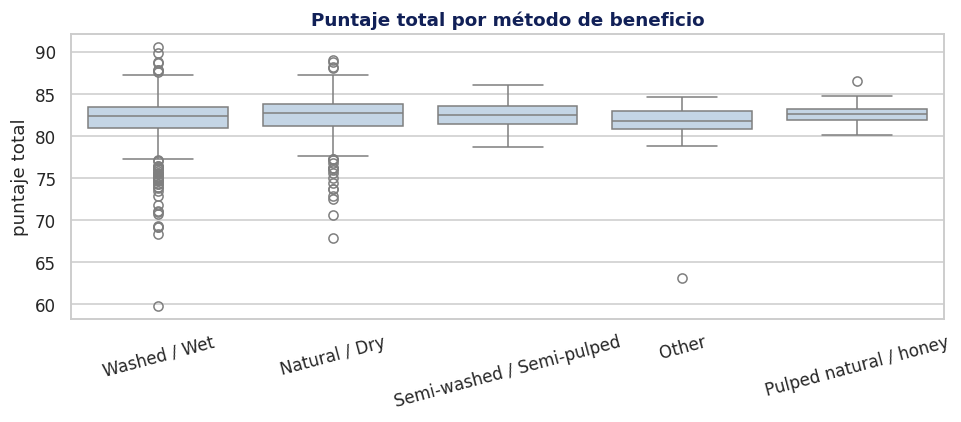

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))

orden_metodos = lotes_limpios["processing_method"].value_counts().index

sns.boxplot(data=lotes_limpios, x="processing_method", y="total_cup_points",
            order=orden_metodos, color=AZUL_CLARO, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("puntaje total")
ax.set_title("Puntaje total por método de beneficio")
ax.tick_params(axis="x", labelrotation=15)
plt.tight_layout()
plt.show()

**Lectura.** Las medianas de los cinco métodos caben en un rango de menos de un punto (de 81.8 a 82.8), mientras que la dispersión dentro de cada método es varias veces mayor. Dicho de otro modo: **saber el método de beneficio casi no ayuda a anticipar el puntaje de un lote.**

Hay que leer el gráfico con cuidado, porque los grupos son muy desiguales: los dos métodos dominantes concentran la mayoría de los lotes y los tres restantes tienen muy pocos, de modo que sus cajas son mucho menos confiables. Un número de casos pequeño produce cajas que parecen igual de sólidas que las demás, y no lo son.

---

## 4. Análisis multivariado

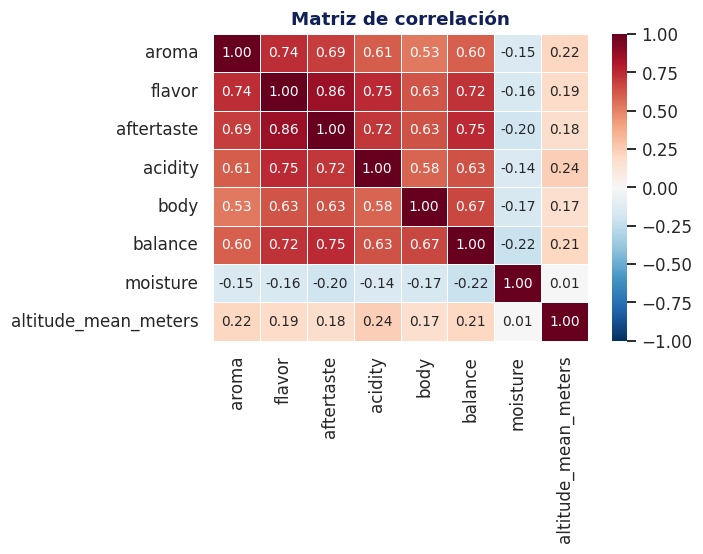

In [24]:
escalas_informativas = ["aroma", "flavor", "aftertaste", "acidity", "body", "balance"]
correlaciones = lotes_limpios[
    escalas_informativas + ["moisture", "altitude_mean_meters"]
].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.2))

# Paleta divergente centrada en cero: el cero es el punto neutro de una correlación,
# así que la escala debe tratarlo como tal y no como un extremo.
sns.heatmap(correlaciones, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 9},
            linewidths=0.6, linecolor="white", ax=ax)

ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

**Lectura.** Las seis subescalas informativas están fuertemente correlacionadas entre sí, entre 0.53 y 0.86. El par más alto es sabor–retrogusto (0.86), lo que sugiere que los catadores no los evalúan de forma independiente. Seis variables muy correlacionadas no aportan seis dimensiones de información: aportan bastante menos.

La altitud y la humedad se comportan de manera muy distinta al bloque sensorial. La altitud tiene correlaciones positivas pero débiles (0.17 a 0.24) y la humedad, negativas y también débiles (−0.14 a −0.22). Son asociaciones en el sentido que la intuición sugeriría —más altura y menos humedad acompañan mejores notas— pero demasiado tenues para explicar gran cosa por sí solas. La creencia de que el café de altura puntúa claramente mejor no se sostiene en estos datos como relación lineal.

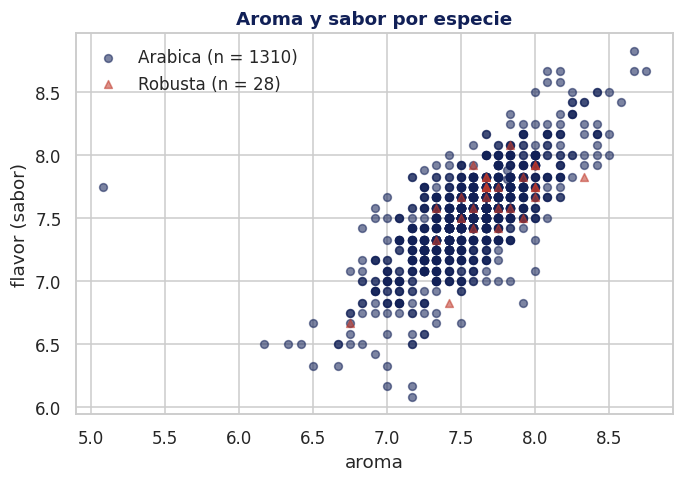

In [25]:
fig, ax = plt.subplots(figsize=(7, 4.5))

# El color lleva aquí una variable categórica, no decoración: la especie. La forma
# también se distingue, para que la figura siga siendo legible sin color.
for especie, marcador, color in [("Arabica", "o", AZUL_OSCURO), ("Robusta", "^", ROJO)]:
    subconjunto = lotes_limpios[lotes_limpios["species"] == especie]
    ax.scatter(subconjunto["aroma"], subconjunto["flavor"], marker=marcador,
               color=color, s=26, alpha=0.55, label=f"{especie} (n = {len(subconjunto)})")

ax.set_xlabel("aroma")
ax.set_ylabel("flavor (sabor)")
ax.set_title("Aroma y sabor por especie")
ax.legend(frameon=False)
plt.show()

**Lectura.** Las dos especies ocupan la misma región del espacio aroma–sabor, sin separarse. Lo que sí salta a la vista es el desbalance: 1310 lotes de arábica contra 28 de robusta. Cualquier conclusión sobre robusta descansa sobre menos del 3 % de los datos.

Nótese que la especie se codifica con color **y** con forma. Si el color se pierde —impresión en blanco y negro, o un lector con deficiencia en la visión del color— la figura sigue siendo legible.

---

## 5. Las mismas conclusiones, mal graficadas

Esta sección se sale del análisis. Está aquí porque el efecto de una mala decisión de codificación se ve mucho mejor sobre datos reales que sobre un ejemplo inventado.

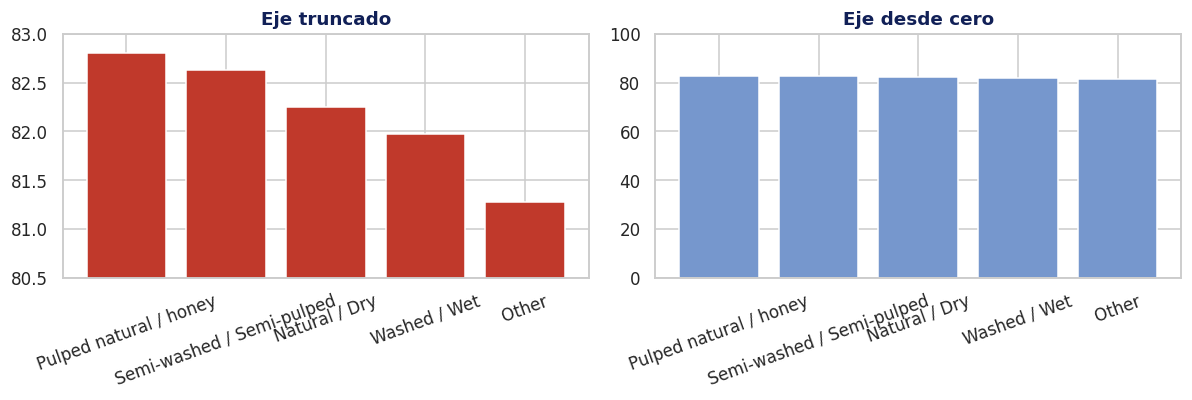

In [26]:
media_por_metodo = (
    lotes_limpios.groupby("processing_method")["total_cup_points"]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].bar(media_por_metodo.index, media_por_metodo.values, color=ROJO)
axes[0].set_ylim(80.5, 83)                       # el eje arranca donde conviene
axes[0].set_title("Eje truncado")
axes[0].tick_params(axis="x", labelrotation=20)

axes[1].bar(media_por_metodo.index, media_por_metodo.values, color=AZUL)
axes[1].set_ylim(0, 100)                         # el eje arranca en cero
axes[1].set_title("Eje desde cero")
axes[1].tick_params(axis="x", labelrotation=20)

plt.tight_layout()
plt.show()

**Lectura.** Los dos paneles grafican exactamente los mismos cinco promedios. El izquierdo sugiere que el método de beneficio produce diferencias enormes de calidad; el derecho muestra que las diferencias son de punto y medio sobre una escala de cien, es decir, prácticamente nada. El diagrama de caja de la sección 3 ya nos había dicho cuál de las dos lecturas es la correcta.

El eje truncado no siempre es un engaño: hay dominios donde el cero no es informativo. La regla útil es que un eje truncado se anuncia, no se disimula.

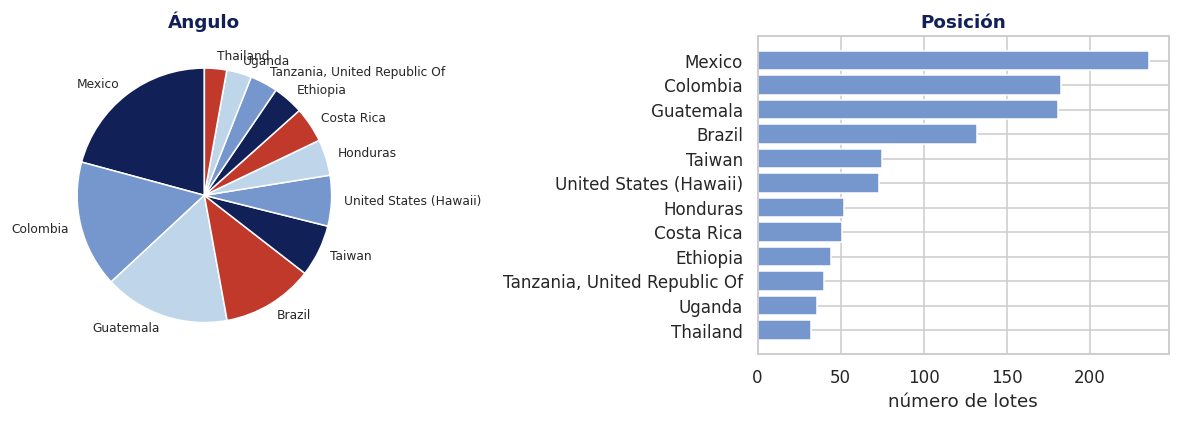

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie(paises_principales.values, labels=paises_principales.index,
            startangle=90, textprops={"size": 8})
axes[0].set_title("Ángulo")

axes[1].barh(paises_principales.index[::-1], paises_principales.values[::-1], color=AZUL)
axes[1].set_title("Posición")
axes[1].set_xlabel("número de lotes")

plt.tight_layout()
plt.show()

**Lectura.** Mismos doce países, mismos conteos. En el pastel es imposible decir si México tiene más lotes que Colombia sin leer las etiquetas; en las barras el orden se lee sin esfuerzo. Ninguna de las dos figuras está «mal hecha»: la diferencia es que una codifica en ángulo y la otra en posición.

---

## 6. Hallazgos y trabajo pendiente

### Hallazgos

1. **`total_cup_points` es la suma de las diez subescalas**, no una medición independiente (diferencia máxima de 0.5 por redondeo). Usarla como variable objetivo junto con las subescalas como predictoras sería fuga de información.
2. **Tres subescalas están saturadas.** `uniformity`, `clean_cup` y `sweetness` tienen mediana 10 y desviación estándar cercana a 0.5: aportan muy poca información discriminante.
3. **Las seis subescalas informativas son redundantes entre sí**, con correlaciones de 0.53 a 0.86. La dimensionalidad efectiva del bloque sensorial es bastante menor que seis.
4. **La ausencia de altitud no es aleatoria**: va del 14 % en Guatemala al 97 % en Hawái. Eliminar las filas sin altitud eliminaría un origen completo.
5. **El conjunto está muy desbalanceado por especie**: 1310 lotes de arábica contra 28 de robusta.

### Preguntas que abre el conjunto

- Si el puntaje total es redundante, ¿cuál es la variable objetivo interesante? ¿La especie, el origen, el método de beneficio?
- ¿Las correlaciones entre subescalas reflejan la calidad del café o el comportamiento de los catadores al llenar la ficha?
- ¿Por qué Hawái casi nunca reporta altitud? ¿Es una diferencia de protocolo del socio certificador?

### Problemas que habría que corregir antes de cualquier análisis posterior

- Las altitudes fuera de rango quedaron marcadas como faltantes, pero no recuperadas. Algunas parecen estar en pies y podrían convertirse.
- `harvest_year` quedó reducida al primer año; se perdió la información de las cosechas que abarcan dos temporadas.
- `variety` tiene 29 niveles con frecuencias muy desiguales; habría que agrupar los minoritarios.
- El desbalance por especie tendría que atenderse antes de cualquier comparación entre arábica y robusta.

Varios de estos pendientes son, exactamente, el tema de las próximas sesiones.

---

### Declaración de uso de IA generativa

Este notebook fue elaborado con apoyo de Claude (Anthropic) para estructurar el contenido a partir de las diapositivas de la sesión, redactar el texto explicativo y seleccionar el conjunto de datos de ejemplo. El diseño pedagógico, la selección de temas y la revisión final son responsabilidad del titular del curso.

### Referencias

- VanderPlas, J. (2022). *Python Data Science Handbook*, 2a ed. O'Reilly. [Capítulo 4: Visualización con Matplotlib](https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html)
- Anscombe, F. J. (1973). Graphs in statistical analysis. *The American Statistician*, 27(1), 17-21.
- Cleveland, W. S., & McGill, R. (1984). Graphical perception: theory, experimentation, and application to the development of graphical methods. *Journal of the American Statistical Association*, 79(387), 531-554.
- Tufte, E. R. (2001). *The Visual Display of Quantitative Information*, 2a ed. Graphics Press.
- Matejka, J., & Fitzmaurice, G. (2017). Same stats, different graphs: generating datasets with varied appearance and identical statistics. *CHI Conference on Human Factors in Computing Systems*.
- Crameri, F., Shephard, G. E., & Heron, P. J. (2020). The misuse of colour in science communication. *Nature Communications*, 11, 5444.
- [Matplotlib: Quick start guide](https://matplotlib.org/stable/users/explain/quick_start.html)
- [seaborn: User guide and tutorial](https://seaborn.pydata.org/tutorial.html)
- Conjunto de datos: [coffee-quality-database](https://github.com/jldbc/coffee-quality-database) · [TidyTuesday 2020-07-07](https://github.com/rfordatascience/tidytuesday/tree/master/data/2020/2020-07-07)